# Efficient Frontier 2

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import edhec_risk_kit as erk

ind = erk.get_ind_returns()
er = erk.annualized_rets(ind["1995":"2000"], periods_per_year=12)
cov = ind["1995":"2000"].cov()

/home/jamesb/repos/EDHEC/01 Intro to Portfolio Construction and Analysis/mod-02/edhec_risk_kit.py:52: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ind = pd.read_csv(


<Axes: title={'center': 'Annualized Returns 1995-2000'}>

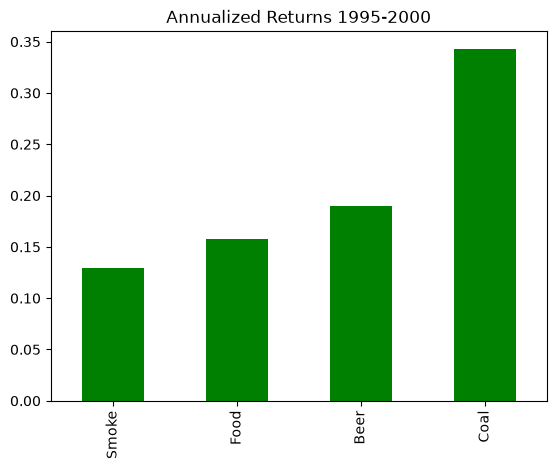

In [2]:
l = ["Food", "Beer", "Smoke", "Coal"]
er[l].sort_values().plot.bar(title="Annualized Returns 1995-2000", color="green")

In [3]:
import numpy as np

In [4]:
er[l]

Food     0.157362
Beer     0.190134
Smoke    0.129288
Coal     0.343089
dtype: float64

In [ ]:
weights = np.repeat(1 / len(l), len(l))
weights

array([0.25, 0.25, 0.25, 0.25])

In [8]:
erk.portfolio_return(weights, er[l])

np.float64(0.20496820684146116)

In [9]:
erk.portfolio_vol(weights, cov.loc[l, l])

np.float64(0.05100412722141178)

### Two Asset Frontier

In [10]:
l = ["Games", "Fin"]

In [11]:
n_points = 20
weights = [np.array([w, 1 - w]) for w in np.linspace(0, 1, n_points)]
weights

[array([0., 1.]),
 array([0.05263158, 0.94736842]),
 array([0.10526316, 0.89473684]),
 array([0.15789474, 0.84210526]),
 array([0.21052632, 0.78947368]),
 array([0.26315789, 0.73684211]),
 array([0.31578947, 0.68421053]),
 array([0.36842105, 0.63157895]),
 array([0.42105263, 0.57894737]),
 array([0.47368421, 0.52631579]),
 array([0.52631579, 0.47368421]),
 array([0.57894737, 0.42105263]),
 array([0.63157895, 0.36842105]),
 array([0.68421053, 0.31578947]),
 array([0.73684211, 0.26315789]),
 array([0.78947368, 0.21052632]),
 array([0.84210526, 0.15789474]),
 array([0.89473684, 0.10526316]),
 array([0.94736842, 0.05263158]),
 array([1., 0.])]

In [12]:
l

['Games', 'Fin']

In [14]:
import pandas as pd

<Axes: title={'center': 'Efficient Frontier'}, xlabel='Volatility', ylabel='Returns'>

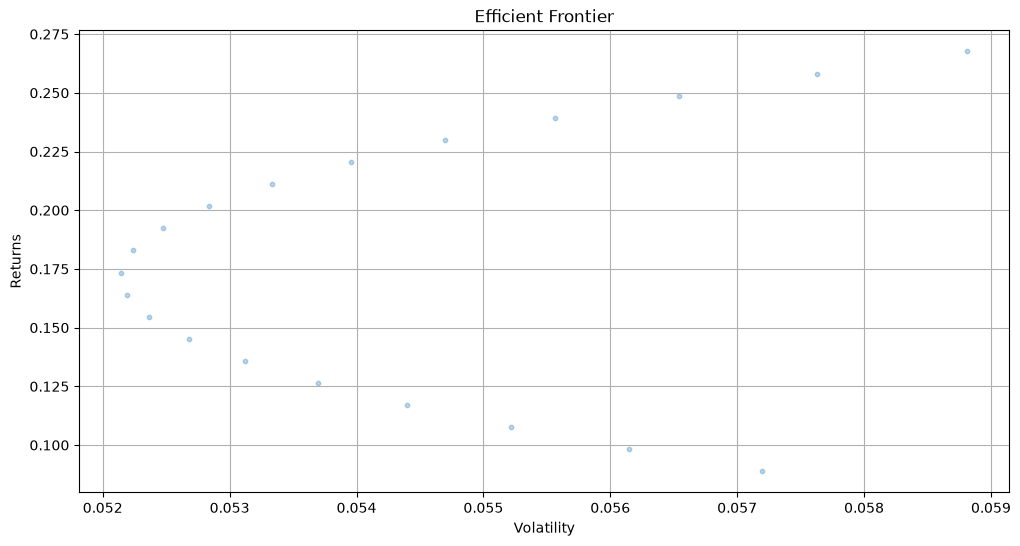

In [ ]:
rets = [erk.portfolio_return(w, er[l]) for w in weights]
vols = [erk.portfolio_vol(w, cov.loc[l, l]) for w in weights]
ef = pd.DataFrame({"Returns": rets, "Volatility": vols})
ef.plot.scatter(
    x="Volatility",
    y="Returns",
    figsize=(12, 6),
    grid=True,
    marker="o",
    s=10,
    alpha=0.3,
    title="Efficient Frontier",
)

<Axes: xlabel='Volatility'>

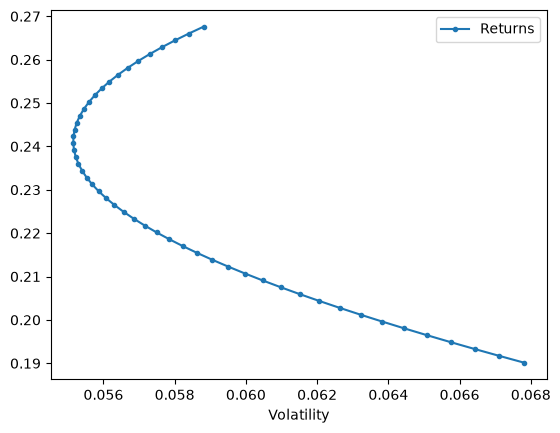

In [ ]:
l = ["Fin", "Beer"]
erk.plot_ef2(50, er[l], cov.loc[l, l], style=".-")